In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd

In [9]:
source_size = 100
n_task = 100

In [10]:
source_activity_pattern = np.random.randn(n_task,source_size)
source_corr = np.corrcoef(source_activity_pattern)

rows, cols = np.triu_indices(source_corr.shape[0], k=1)
source_corr_upper = source_corr[rows, cols]

In [11]:
def generate_conn(source_size=10,target_size=10,conn_dim = 10):
    
    U = np.random.randn(source_size,conn_dim)
    V = np.random.randn(conn_dim,target_size)
    conn = U@V

    return conn

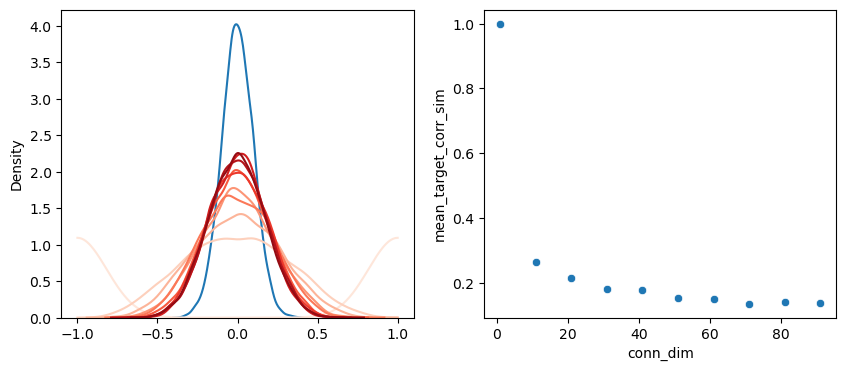

In [15]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

sns.kdeplot(source_corr_upper,clip=(-1,1),label='source',ax=ax[0])

target_size = 100
conn_dim_max = int(np.min([source_size,target_size]))
target_corr_possim = np.zeros(10)

palette = sns.color_palette("Reds", n_colors=10)

for i,conn_dim in enumerate(np.arange(1,conn_dim_max+1,10)):

    conn = generate_conn(source_size=source_size,
                         target_size=target_size,
                         conn_dim=conn_dim)

    target_activity_pattern = source_activity_pattern@conn
    target_corr = np.corrcoef(target_activity_pattern)

    rows, cols = np.triu_indices(target_corr.shape[0], k=1)
    target_corr_upper = target_corr[rows, cols]
    target_corr_possim[i] = np.mean(target_corr_upper[target_corr_upper>0])

    sns.kdeplot(target_corr_upper,clip=(-1,1),label='dim_'+str(conn_dim),color=palette[i],ax=ax[0])

# ax[0].legend()

df = pd.DataFrame({
    'conn_dim': np.arange(1,conn_dim_max+1,10),
    'mean_target_corr_sim': target_corr_possim
})

sns.scatterplot(x='conn_dim', y='mean_target_corr_sim', data=df,ax=ax[1])

plt.show()

In [6]:
def get_mean_target_corr_possim(source_activity_pattern,source_size=10,target_size=10):

    conn_dim_max = int(np.min([source_size,target_size]))
    target_corr_possim = np.zeros(conn_dim_max)
    for i,conn_dim in enumerate(range(1,conn_dim_max+1)):
    
        conn = generate_conn(source_size=source_size,
                             target_size=target_size,
                             conn_dim=conn_dim)
    
        target_activity_pattern = source_activity_pattern@conn
        target_corr = np.corrcoef(target_activity_pattern)
    
        rows, cols = np.triu_indices(target_corr.shape[0], k=1)
        target_corr_upper = target_corr[rows, cols]
        target_corr_possim[i] = np.mean(target_corr_upper[target_corr_upper>0])

    return target_corr_possim

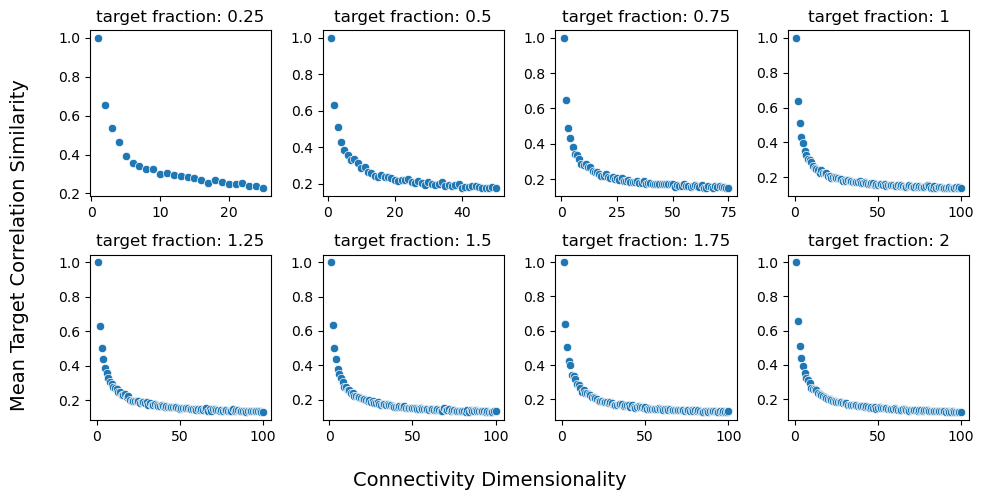

In [7]:
# Function of target size

fig, ax = plt.subplots(2, 4, figsize=(10, 5))
target_frac_list = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]

for i, target_frac in enumerate(target_frac_list):
    target_size = int(np.floor(source_size*target_frac))
    target_corr_possim = get_mean_target_corr_possim(source_activity_pattern,
                                source_size=source_size,
                                target_size=target_size)    
    df = pd.DataFrame({
        'conn_dim': range(1, len(target_corr_possim)+1),
        'mean_target_corr_sim': target_corr_possim
    })
    row = i//4
    col = i%4
    sns.scatterplot(x='conn_dim', y='mean_target_corr_sim', data=df, ax=ax[row, col])
    ax[row, col].set_title('target fraction: '+str(target_frac))
    
    # Remove individual x and y labels
    ax[row, col].set_xlabel('')
    ax[row, col].set_ylabel('')

# Add single x and y labels for the entire figure
fig.supxlabel('Connectivity Dimensionality', fontsize=14)
fig.supylabel('Mean Target Correlation Similarity', fontsize=14)

# Adjust the layout to make room for the labels
plt.tight_layout()
# Add some padding at the bottom and left for the labels
plt.subplots_adjust(left=0.1, bottom=0.15)

plt.show()

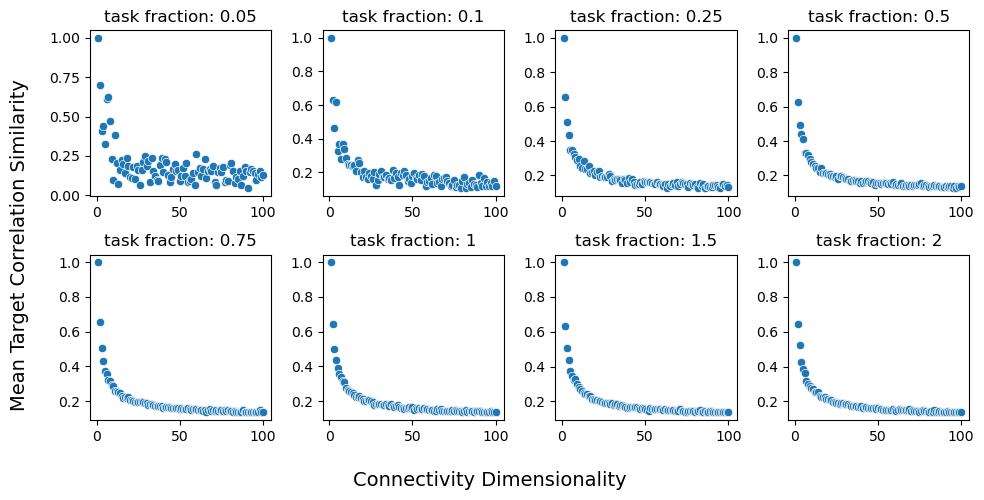

In [19]:
# Function of number of tasks given source and target sizes

fig, ax = plt.subplots(2, 4, figsize=(10, 5))
task_frac_list = [0.05,0.1,0.25,0.5,0.75,1,1.5,2]

source_size = 100
target_size = 100

for i, task_frac in enumerate(task_frac_list):
    n_task = int(np.floor(source_size*task_frac))
    source_activity_pattern = np.random.randn(n_task,source_size)
    
    target_corr_possim = get_mean_target_corr_possim(source_activity_pattern,
                                source_size=source_size,
                                target_size=target_size)    
    df = pd.DataFrame({
        'conn_dim': range(1, len(target_corr_possim)+1),
        'mean_target_corr_sim': target_corr_possim
    })
    row = i//4
    col = i%4
    sns.scatterplot(x='conn_dim', y='mean_target_corr_sim', data=df, ax=ax[row, col])
    ax[row, col].set_title('task fraction: '+str(task_frac))
    
    # Remove individual x and y labels
    ax[row, col].set_xlabel('')
    ax[row, col].set_ylabel('')

# Add single x and y labels for the entire figure
fig.supxlabel('Connectivity Dimensionality', fontsize=14)
fig.supylabel('Mean Target Correlation Similarity', fontsize=14)

# Adjust the layout to make room for the labels
plt.tight_layout()
# Add some padding at the bottom and left for the labels
plt.subplots_adjust(left=0.1, bottom=0.15)

plt.show()